In [1]:
import numpy as np
import neuromaps.datasets
from matplotlib import pyplot as plt
from PIL import Image

import yaspy

import flat_mae.transforms as flat_transforms
import flat_mae.nisc as nisc

In [2]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad

In [4]:
input_spaces = ["schaefer400", "flat", "mni_cortex"]

grads = {}
for space in input_spaces:
    grads[space] = np.load(f"results/pca_{space}.npz")["components"]

2026-01-27 12:09:11.378 (  34.403s) [    7D3584822740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


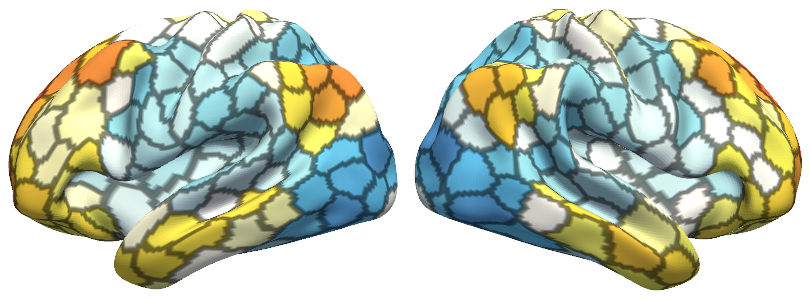

In [5]:
parc_path = nisc.fetch_schaefer(400, space="fslr64k")
parc = nisc.read_cifti_surf_data(parc_path).squeeze(0).astype(np.int64)

bold = -grads["schaefer400"][0]
bold = bold / bold.std()
bold_ = np.zeros(parc.size, dtype=bold.dtype)
bold_[parc > 0] = bold[parc[parc > 0] - 1]
bold = bold_
bold_l, bold_r = np.split(bold, 2)
parc_l, parc_r = np.split(parc, 2)

surfaces = neuromaps.datasets.fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]

plotter_l = yaspy.Plotter(surf_lh_path, hemi="lh", width=384)
plotter_l.overlay(
    np.where(bold_l != 0, bold_l, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_l.border(parc_l, alpha=0.5)

for light in plotter_l._plotter.renderer.lights:
    light.intensity *= 1.3

img_l = plotter_l.screenshot()

plotter_r = yaspy.Plotter(surf_rh_path, hemi="rh", width=384)
plotter_r.overlay(
    np.where(bold_r != 0, bold_r, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_r.border(parc_r, alpha=0.5)

for light in plotter_r._plotter.renderer.lights:
    light.intensity *= 1.3
img_r = plotter_r.screenshot()

img = yaspy.montage([[img_l, img_r]], pad=8)
img.save("results/pca_schaefer400.png")
img

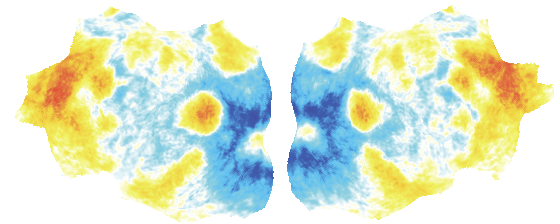

In [6]:
bold = grads["flat"][0]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("flat")
bold_ = np.zeros(unmask.mask.shape, dtype=bold.dtype)
bold_[unmask.mask.numpy()] = bold
bold = bold_

mask = bold != 0
cmap = nisc.FC_CMAP
cmap.set_bad("none")
vmax = 3
bold = np.where(mask, bold, np.nan)
img = cmap(np.clip((bold + vmax) / (2 * vmax), 0, 1))
img = (255 * img).astype(np.uint8)
img = Image.fromarray(img)
img.save("results/pca_flat.png")
img

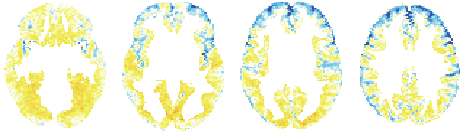

In [7]:
bold = grads["mni_cortex"][0]
bold = bold / bold.std()

unmask = flat_transforms.get_unmask("mni_cortex")
bold_ = np.zeros(unmask.mask.shape, dtype=bold.dtype)
bold_[unmask.mask.numpy()] = bold
bold = bold_

mask = bold != 0
zids, yids, xids = mask.nonzero()
ymin = yids.min() - 1
ymax = yids.max()
xmin = xids.min() - 1
xmax = xids.max()

nc = 4
f, axs = plt.subplots(1, nc)

start = 28
stride = 7

cmap = nisc.FC_CMAP
cmap.set_bad("none")

for ii, ax in enumerate(axs):
    plt.sca(ax)
    idx = start + ii * stride
    img = bold[idx, ymin:ymax, xmin:xmax]
    plt.imshow(
        np.where(img != 0, img, np.nan),
        cmap=cmap,
        vmin=-3,
        vmax=3,
        origin="lower",
        interpolation="none",
    )
    plt.axis("off")

plt.tight_layout()
f.savefig("results/pca_mni_cortex.png", transparent=True, dpi=300)